# 从固定 ideal 基线分批注入 CW

流程只有三步：保存一套 `make_ideal` 后的基线；每个频率批次都从它深复制；每批写入自己的目录且不覆盖旧结果。

## 1. 导入

In [1]:
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from pint import toa as pint_toa
from pint.logging import setup as setup_pint_logging
from pint.models import get_model
from pint.residuals import Residuals
from pta_replicator.deterministic import add_cgw
from pta_replicator.simulate import SimulatedPulsar, make_ideal, simulate_pulsar

setup_pint_logging(level="WARNING")

libstempo not installed. PINT or libstempo are required to use par and tim files.


1

## 2. 参数

In [2]:
obstime = np.arange(53000, 56650, 14)
N_PSR = 25

T_seconds = (obstime[-1] - obstime[0]) * 86400.0
f = 1.0 / T_seconds

source_ra = np.deg2rad(2.0)
source_dec = np.deg2rad(0.4)
gwphi = source_ra
gwtheta = np.pi / 2.0 - source_dec

# 增加频率时，只需在这里多写一行。
CW_BATCHES = [
    {"label": "k5p5", "k0": 5, "delta": 0.5},
]
ANALYSIS_BATCH = "k5p5"

assert len({item["label"] for item in CW_BATCHES}) == len(CW_BATCHES)
assert ANALYSIS_BATCH in {item["label"] for item in CW_BATCHES}

In [3]:
template_par = Path("data/JPSR00.par")
data_root = Path("cw_batch_data")
model_par_dir = data_root / "model_par" / "baseline_v1"
ideal_dir = data_root / "ideal" / "baseline_v1"
cw_root = data_root / "cw"
psr_names = [f"J{i:02d}" for i in range(N_PSR)]

## 3. 生成或加载 ideal 基线

In [4]:
def fibonacci_sphere(n):
    i = np.arange(n)
    golden_ratio = (1 + np.sqrt(5)) / 2
    z = 1 - 2 * (i + 0.5) / n
    ra = np.mod(2 * np.pi * i / golden_ratio, 2 * np.pi)
    dec = np.arcsin(z)
    return ra, dec

In [5]:
def load_ideal_psr(parfile, timfile):
    model = get_model(parfile)

    # 传入 model，确保 PINT 使用 par 文件中的 TT(BIPM2016)。
    toas = pint_toa.get_TOAs(
        timfile, model=model, ephem="DE440", planets=True, usepickle=False
    )

    return SimulatedPulsar(
        ephem="DE440",
        model=model,
        toas=toas,
        residuals=Residuals(toas, model),
        name=model.PSR.value,
        loc={"RAJ": model.RAJ.value, "DECJ": model.DECJ.value},
        added_signals={},
        added_signals_time={},
    )

In [6]:
ra_list, dec_list = fibonacci_sphere(N_PSR)

if not model_par_dir.exists():
    model_par_dir.mkdir(parents=True)

    for name, ra, dec in zip(psr_names, ra_list, dec_list):
        model = get_model(template_par)
        model.PSR.value = name
        model.RAJ.quantity = ra * u.rad
        model.DECJ.quantity = dec * u.rad
        model.setup()
        model.validate()
        model.write_parfile(model_par_dir / f"{name}.par")

parfiles = sorted(model_par_dir.glob("*.par"))
if [path.stem for path in parfiles] != psr_names:
    raise RuntimeError(f"{model_par_dir} 中的 par 文件不完整")

print(f"模型 par 文件：{len(parfiles)} 个")

模型 par 文件：25 个


In [7]:
if not ideal_dir.exists():
    ideal_dir.mkdir(parents=True)

    for parfile in parfiles:
        psr = simulate_pulsar(
            parfile=str(parfile),
            obstimes=obstime,
            toaerr=0.1,
            freq=1440.0,
            observatory="AXIS",
            ephem="DE440",
        )
        make_ideal(psr)
        psr.write_partim(
            ideal_dir / f"{psr.name}.par",
            ideal_dir / f"{psr.name}.tim",
            tempo2=True,
        )
    print("ideal 基线已保存")
else:
    print("ideal 基线已存在，直接使用，不覆盖")

ideal_pars = sorted(ideal_dir.glob("*.par"))
ideal_tims = sorted(ideal_dir.glob("*.tim"))
if [p.stem for p in ideal_pars] != psr_names or [p.stem for p in ideal_tims] != psr_names:
    raise RuntimeError(f"{ideal_dir} 中的 par/tim 文件不完整")

ideal_psrs = [load_ideal_psr(par, tim) for par, tim in zip(ideal_pars, ideal_tims)]
print(f"ideal 脉冲星：{len(ideal_psrs)} 颗，每颗 {len(ideal_psrs[0].toas)} 个 TOA")

ideal 基线已存在，直接使用，不覆盖


ideal 脉冲星：25 颗，每颗 261 个 TOA


## 4. 每个频率从 ideal 独立注入

In [8]:
def inject_cw(ideal_psrs, fgw):
    injected_psrs = deepcopy(ideal_psrs)

    for psr in injected_psrs:
        add_cgw(
            psr=psr,
            gwtheta=gwtheta,
            gwphi=gwphi,
            mc=1.0e9,
            dist=100.0,
            fgw=fgw,
            phase0=0.0,
            psi=0.0,
            inc=np.pi / 3.0,
            psrTerm=False,
            evolve=False,
            phase_approx=False,
            tref=obstime[0] * 86400.0,
            signal_name="cw",
        )

        if set(psr.added_signals) != {f"{psr.name}_cw"}:
            raise RuntimeError(f"{psr.name} 出现重复或意外信号")

    return injected_psrs

In [9]:
ideal_mjds = {psr.name: psr.toas.get_mjds().value.copy() for psr in ideal_psrs}
batch_psrs = {}
batch_frequencies = {}

for batch in CW_BATCHES:
    label = batch["label"]
    fgw = (batch["k0"] + batch["delta"]) * f
    output_dir = cw_root / f"{label}_f{fgw:.12e}Hz"
    injected_psrs = inject_cw(ideal_psrs, fgw)

    if output_dir.exists():
        n_par = len(list(output_dir.glob("*.par")))
        n_tim = len(list(output_dir.glob("*.tim")))
        if (n_par, n_tim) != (N_PSR, N_PSR):
            raise RuntimeError(f"{output_dir} 已存在但文件不完整")
        action = "已存在，不覆盖"
    else:
        output_dir.mkdir(parents=True)
        for psr in injected_psrs:
            psr.write_partim(
                output_dir / f"{psr.name}.par",
                output_dir / f"{psr.name}.tim",
                tempo2=True,
            )
        action = "已保存"

    batch_psrs[label] = injected_psrs
    batch_frequencies[label] = fgw
    print(f"{label}: fgw={fgw:.15e} Hz，{action} -> {output_dir}")

for psr in ideal_psrs:
    assert np.array_equal(psr.toas.get_mjds().value, ideal_mjds[psr.name])
    assert psr.added_signals == {}

psrs = batch_psrs[ANALYSIS_BATCH]
fgw = batch_frequencies[ANALYSIS_BATCH]

k5p5: fgw=1.748829873829874e-08 Hz，已存在，不覆盖 -> cw_batch_data/cw/k5p5_f1.748829873830e-08Hz


## 5. 查看所选批次

### 残差诊断的修正与原因

这里验证的是 **固定计时模型下的 CW 注入增量**，不是重新拟合后的 residual。

1. 比较 $\Delta r=r_{\rm after}-r_{\rm before}$，扣除 ideal 基线中仍可能存在的数值/读写残差。
2. 当前模型没有显式 PHOFF，PINT 默认减去加权均值，因此理论 CW 也必须使用同一权重：$s_\perp=s-\sum_i w_i s_i/\sum_i w_i$，$w_i=1/\sigma_i^2$。权重从 PINT 的 `get_data_error()` 取得。
3. 同时保留 `subtract_mean=False` 的 raw 增量检查；不能仅因中心化后的差值均值为零，就认定注入正确。
4. 单独报告 mean、std、真正的 RMS $=\sqrt{\mathrm{mean}(e^2)}$ 和最大绝对误差。原代码把 `np.std` 标作 RMS，会漏掉常数偏置。

5.5 个周期的有限采样 CW 均值一般不为零，所以原来的 `PINT residual - raw CW` 可以带有常数偏移，并不单独证明 CW 波形错误。新图依次显示 PINT 增量、相同零点约定下的 CW、二者差值；最后一幅保留真实数值误差，不强行置零。代码对全部 25 颗脉冲星同时检查 raw / centered 两条路径。

本节不修改 CW 波形、TOA、计时模型或后续 enterprise 输入。仅去除 Offset 也不等同于一般的 timing-model fit。

官方参考：[PINT Residuals 参数与权重](https://nanograv-pint.readthedocs.io/en/stable/_autosummary/pint.residuals.Residuals.html)、[PINT 相位零点说明](https://nanograv-pint.readthedocs.io/en/latest/explanation.html#offsets-in-pulsar-timing)。

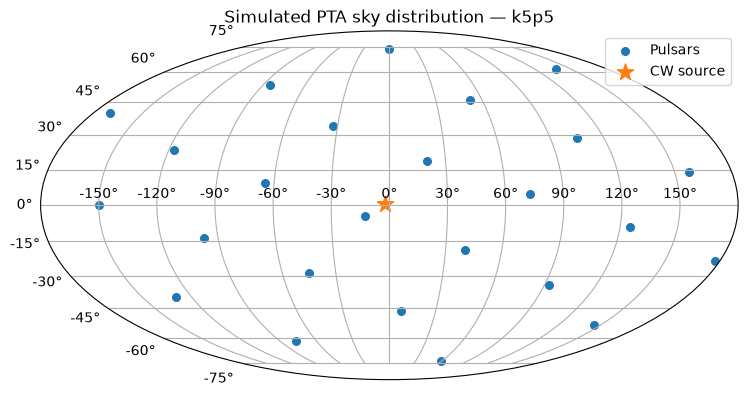

In [10]:
ra = np.array([psr.model.RAJ.quantity.to_value(u.rad) for psr in psrs])
dec = np.array([psr.model.DECJ.quantity.to_value(u.rad) for psr in psrs])
ra_wrapped = (ra + np.pi) % (2.0 * np.pi) - np.pi
source_ra_wrapped = (source_ra + np.pi) % (2.0 * np.pi) - np.pi

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(-ra_wrapped, dec, s=30, label="Pulsars")
ax.scatter(-source_ra_wrapped, source_dec, marker="*", s=150, label="CW source")
ax.grid()
ax.legend()
ax.set_title(f"Simulated PTA sky distribution — {ANALYSIS_BATCH}")
plt.show()

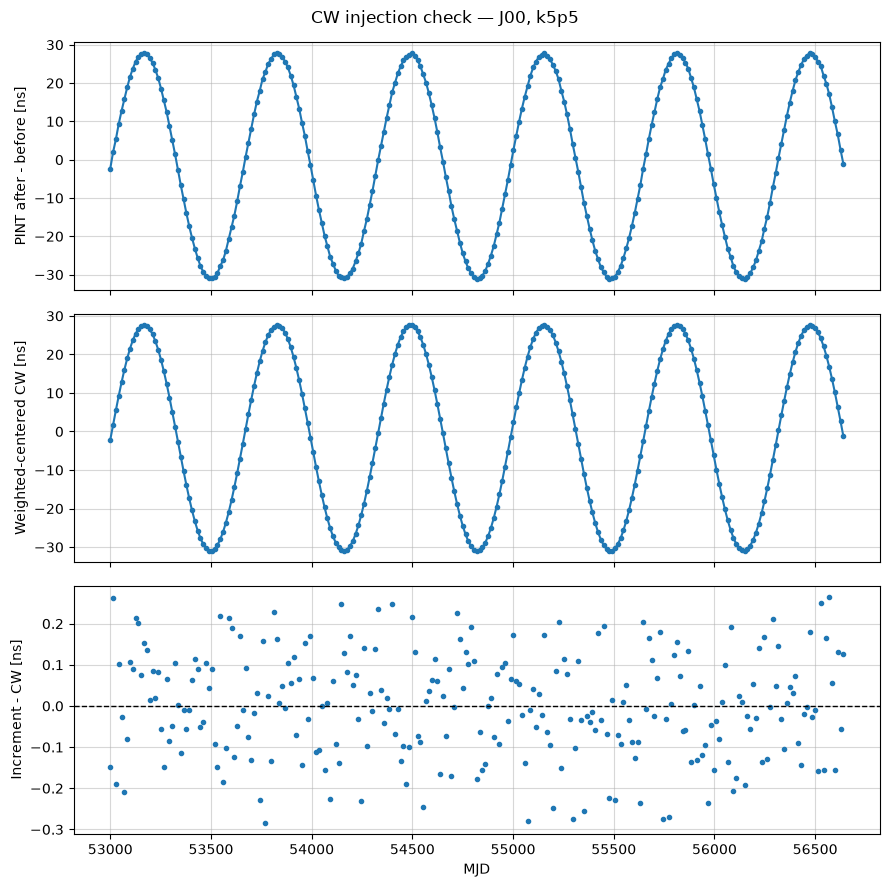

1/T [Hz]: 3.17969067969068e-09
CW frequency [Hz]: 1.748829873829874e-08
Selected pulsar: J00
Weighted CW mean removed [ns]: 1.6866536555513036
baseline: {'mean_ns': 9.720433270559695e-20, 'std_ns': 0.3048738706216134, 'rms_ns': 0.3048738706216134, 'max_abs_ns': 0.6915824059935775}
legacy: {'mean_ns': -1.686653655551304, 'std_ns': 0.3005427445820514, 'rms_ns': 1.713221087631567, 'max_abs_ns': 2.464850534522585}
raw: {'mean_ns': 0.012946297067053405, 'std_ns': 0.12632148284343506, 'rms_ns': 0.12698316280323407, 'max_abs_ns': 0.27797631843906845}
projected: {'mean_ns': -3.582677537461698e-16, 'std_ns': 0.12632148284343503, 'rms_ns': 0.12632148284343503, 'max_abs_ns': 0.283526808617493}
Relative RMS (projected): 0.006128738793485515
CW residual amplitude [ns]: 29.300337230999915
All 25 pulsars, raw: worst RMS=0.131717 ns, max=0.325291 ns
All 25 pulsars, projected: worst RMS=0.131511 ns, max=0.320177 ns
PASS: raw and weighted-centered CW injection checks


In [11]:
def cw_weighted_center(values, weights):
    """使用与 PINT 相同的权重去均值；不修改输入数组。"""
    return values - np.average(values, weights=weights)


def cw_error_stats(error):
    """RMS 包括系统偏置，不能用标准差代替。"""
    return {
        "mean_ns": float(np.mean(error)),
        "std_ns": float(np.std(error)),
        "rms_ns": float(np.sqrt(np.mean(error**2))),
        "max_abs_ns": float(np.max(np.abs(error))),
    }


def diagnose_cw_injection(ideal_psr, injected_psr):
    """固定计时模型下的注入检查，不拟合、不修改 TOA/模型/信号。"""
    if ideal_psr.name != injected_psr.name:
        raise ValueError("ideal 与 injected 脉冲星必须同名")
    if ideal_psr.model.as_parfile(include_info=False) != injected_psr.model.as_parfile(include_info=False):
        raise ValueError("注入前后计时模型不一致，不能只比较 CW 增量")
    if "PhaseOffset" in ideal_psr.model.components:
        raise ValueError("本诊断针对隐式 Offset；显式 PHOFF 需要另行处理")
    if not np.array_equal(ideal_psr.toas.table["index"], injected_psr.toas.table["index"]):
        raise ValueError("注入前后 TOA 的数量或行顺序不一致")
    cw_key = f"{injected_psr.name}_cw"
    if set(injected_psr.added_signals_time) != {cw_key}:
        raise ValueError("需要且只能包含一次 CW 注入")

    # 重新计算，而不是直接复用 psr.residuals 的缓存。
    before = Residuals(ideal_psr.toas, ideal_psr.model,
                       subtract_mean=True, use_weighted_mean=True)
    after = Residuals(injected_psr.toas, injected_psr.model,
                      subtract_mean=True, use_weighted_mean=True)
    sigma = before.get_data_error().to_value(u.ns)
    if not np.array_equal(sigma, after.get_data_error().to_value(u.ns)):
        raise ValueError("注入前后 TOA 权重改变")
    if not np.all(np.isfinite(sigma) & (sigma > 0)):
        raise ValueError("TOA uncertainty 必须为有限正数")
    weights = sigma**-2
    baseline = before.time_resids.to_value(u.ns)
    total = after.time_resids.to_value(u.ns)
    cw_raw = injected_psr.added_signals_time[cw_key].to_value(u.ns)
    if cw_raw.shape != baseline.shape or not np.all(np.isfinite(cw_raw)):
        raise ValueError("CW 数组长度不匹配或包含非有限值")
    cw_projected = cw_weighted_center(cw_raw, weights)
    delta_pint = total - baseline
    difference = delta_pint - cw_projected

    # 独立的 raw 检查保留常数偏置，防止去均值掩盖真实误差。
    before_raw = Residuals(ideal_psr.toas, ideal_psr.model,
                           subtract_mean=False, use_weighted_mean=True)
    after_raw = Residuals(injected_psr.toas, injected_psr.model,
                          subtract_mean=False, use_weighted_mean=True)
    delta_raw = after_raw.time_resids.to_value(u.ns) - before_raw.time_resids.to_value(u.ns)
    raw_difference = delta_raw - cw_raw
    legacy_difference = total - cw_raw
    cw_mean = np.average(cw_raw, weights=weights)
    np.testing.assert_allclose(
        legacy_difference, difference + baseline - cw_mean, rtol=0, atol=1e-10
    )
    return {
        "pulsar": injected_psr.name,
        "delta_pint": delta_pint, "cw_projected": cw_projected,
        "difference": difference, "cw_raw": cw_raw,
        "cw_mean_ns": float(cw_mean),
        "baseline": cw_error_stats(baseline),
        "legacy": cw_error_stats(legacy_difference),
        "raw": cw_error_stats(raw_difference),
        "projected": cw_error_stats(difference),
    }


ideal_by_name = {item.name: item for item in ideal_psrs}
cw_diagnostics = [diagnose_cw_injection(ideal_by_name[item.name], item) for item in psrs]
selected_diagnostic = cw_diagnostics[0]
psr = psrs[0]
# 绘图使用注入前采样时刻；不通过相减 float64 MJD 测量 ns 级 TOA 位移。
toa_mjd = ideal_by_name[psr.name].toas.get_mjds().value
delta_pint = selected_diagnostic["delta_pint"]
cw_projected = selected_diagnostic["cw_projected"]
difference = selected_diagnostic["difference"]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(toa_mjd, delta_pint, ".-")
axes[0].set_ylabel("PINT after - before [ns]")
axes[1].plot(toa_mjd, cw_projected, ".-")
axes[1].set_ylabel("Weighted-centered CW [ns]")
axes[2].plot(toa_mjd, difference, ".")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Increment - CW [ns]")
axes[2].set_xlabel("MJD")
for ax in axes:
    ax.grid(alpha=0.5)
fig.suptitle(f"CW injection check — {psr.name}, {ANALYSIS_BATCH}")
plt.tight_layout()
plt.show()

print("1/T [Hz]:", f)
print("CW frequency [Hz]:", fgw)
print("Selected pulsar:", psr.name)
print("Weighted CW mean removed [ns]:", selected_diagnostic["cw_mean_ns"])
for convention in ("baseline", "legacy", "raw", "projected"):
    print(f"{convention}:", selected_diagnostic[convention])
signal_rms = np.sqrt(np.mean(cw_projected**2))
relative_rms = selected_diagnostic["projected"]["rms_ns"] / signal_rms if signal_rms > 0 else np.nan
print("Relative RMS (projected):", relative_rms)
print("CW residual amplitude [ns]:", 0.5 * np.ptp(selected_diagnostic["cw_raw"]))
for convention in ("raw", "projected"):
    worst_rms = max(item[convention]["rms_ns"] for item in cw_diagnostics)
    worst_max = max(item[convention]["max_abs_ns"] for item in cw_diagnostics)
    print(f"All {len(cw_diagnostics)} pulsars, {convention}: worst RMS={worst_rms:.6g} ns, max={worst_max:.6g} ns")
    assert worst_rms < 1.0 and worst_max < 3.0, f"{convention} 注入检查超出数值容差"
print("PASS: raw and weighted-centered CW injection checks")

## 6. 转为 enterprise Pulsar

In [12]:
from enterprise.pulsar import Pulsar

enterprise_psrs = [
    Pulsar(psr.toas, psr.model, timing_package="pint", planets=False)
    for psr in psrs
]

for psr in enterprise_psrs[:3]:
    print(psr.name, len(psr.toas), psr.toas.min(), psr.toas.max())

J00 261 4579200239.467906 4893696271.779491
J01 261 4579200104.933258 4893696069.911834
J02 261 4579200484.73054 4893696491.279551
